
# 07 — DistilBERT, Robustness Check, Figures

Notebook purpose: experiment with DistilBERT and begin final-results consolidation.

distilbert-base-uncased, class-weighted cross-entropy, early stopping based on validation Macro F1, primary held-out-park evaluation, secondary mixed-park evaluation, comparison with all prior models, grouped cross-validation robustness check for the sentence-embedding model




## 1. Colab setup
Select

**Runtime → Change runtime type → T4 GPU**



In [ ]:

!pip -q install -U transformers datasets accelerate sentence-transformers openpyxl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.4 MB/s eta 0:00:00


## 2. Imports and reproducibility

In [ ]:

from pathlib import Path
import inspect
import json
import os
import random
import warnings
from dataclasses import dataclass
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from datasets import Dataset
from sentence_transformers import SentenceTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
set_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PRIMARY_LABELS = [
    "trail_or_area_access",
    "road_parking_transportation",
    "weather_fire_environmental_hazard",
    "wildlife_hazard_or_restriction",
    "facility_water_campground_service",
    "construction_maintenance_general",
]

DISPLAY_LABELS = {
    "trail_or_area_access": "Trail / area access",
    "road_parking_transportation": "Road / parking / transportation",
    "weather_fire_environmental_hazard": "Weather / fire / environmental",
    "wildlife_hazard_or_restriction": "Wildlife hazard / restriction",
    "facility_water_campground_service": "Facility / campground / service",
    "construction_maintenance_general": "General / minor issue",
}

LABEL_TO_ID = {
    label: index
    for index, label in enumerate(PRIMARY_LABELS)
}
ID_TO_LABEL = {
    index: label
    for label, index in LABEL_TO_ID.items()
}

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256
LEARNING_RATE = 2e-5
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
MAX_EPOCHS = 5
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 2

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)


Device: cuda
PyTorch: 2.11.0+cu128


## 3. Locate required project files

In [ ]:

SEARCH_DIRS = [
    Path("/content"),
    Path("/mnt/data"),
    Path("."),
]

def find_latest_file(patterns, required=True):
    matches = []

    for directory in SEARCH_DIRS:
        for pattern in patterns:
            matches.extend(directory.glob(pattern))

    matches = sorted(
        {path.resolve() for path in matches},
        key=lambda path: path.stat().st_mtime,
    )

    if matches:
        return matches[-1]

    if required:
        raise FileNotFoundError(
            "Could not find any file matching: "
            + ", ".join(patterns)
        )

    return None


MODELING_PATH = find_latest_file([
    "nps_gold_modeling_dataset_with_splits*.csv",
])

BASELINE_METRICS_PATH = find_latest_file([
    "baseline_overall_metrics*.csv",
])

EMBEDDING_METRICS_PATH = find_latest_file([
    "embedding_overall_metrics*.csv",
])

EMBEDDING_CLASS_PATH = find_latest_file([
    "embedding_per_class_metrics*.csv",
])

EMBEDDING_ABLATION_PATH = find_latest_file([
    "embedding_title_ablation*.csv",
], required=False)

print("Modeling data:", MODELING_PATH)
print("Baseline metrics:", BASELINE_METRICS_PATH)
print("Embedding metrics:", EMBEDDING_METRICS_PATH)
print("Embedding class metrics:", EMBEDDING_CLASS_PATH)
print("Embedding ablation:", EMBEDDING_ABLATION_PATH)


Modeling data: /content/nps_gold_modeling_dataset_with_splits.csv
Baseline metrics: /content/baseline_overall_metrics.csv
Embedding metrics: /content/embedding_overall_metrics.csv
Embedding class metrics: /content/embedding_per_class_metrics.csv
Embedding ablation: /content/embedding_title_ablation.csv


## 4. Load and validate the finalized dataset

In [ ]:

modeling_df = pd.read_csv(MODELING_PATH)

required_columns = {
    "id",
    "parkCode",
    "title",
    "description",
    "primary_label",
    "heldout_park_split",
    "mixed_park_split",
}

missing_columns = required_columns - set(modeling_df.columns)
if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

modeling_df["title"] = (
    modeling_df["title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

modeling_df["description"] = (
    modeling_df["description"]
    .fillna("")
    .astype(str)
    .str.strip()
)

modeling_df["text"] = (
    modeling_df["title"]
    + " "
    + modeling_df["description"]
).str.strip()

modeling_df["label_id"] = (
    modeling_df["primary_label"]
    .map(LABEL_TO_ID)
)

if modeling_df["label_id"].isna().any():
    invalid = sorted(
        set(modeling_df.loc[
            modeling_df["label_id"].isna(),
            "primary_label",
        ])
    )
    raise ValueError(f"Unexpected labels: {invalid}")

modeling_df["label_id"] = (
    modeling_df["label_id"]
    .astype(int)
)

assert modeling_df["id"].nunique() == len(modeling_df)
assert modeling_df["text"].ne("").all()

park_partition_counts = (
    modeling_df
    .groupby("parkCode")["heldout_park_split"]
    .nunique()
)
assert (
    park_partition_counts.max() == 1
), "A park appears in multiple held-out partitions."

print("Records:", len(modeling_df))
print("Unique parks:", modeling_df["parkCode"].nunique())

display(
    modeling_df["primary_label"]
    .value_counts()
    .reindex(PRIMARY_LABELS, fill_value=0)
    .rename("count")
    .to_frame()
)

print("Held-out split:")
display(
    pd.crosstab(
        modeling_df["primary_label"],
        modeling_df["heldout_park_split"],
    )
    .reindex(PRIMARY_LABELS, fill_value=0)
    .reindex(
        columns=["train", "validation", "test"],
        fill_value=0,
    )
)


Records: 300
Unique parks: 199


,count
primary_label,
trail_or_area_access,53
road_parking_transportation,86
weather_fire_environmental_hazard,44
wildlife_hazard_or_restriction,20
facility_water_campground_service,84
construction_maintenance_general,13


Held-out split:


heldout_park_split,train,validation,test
primary_label,,,
trail_or_area_access,36,9,8
road_parking_transportation,62,10,14
weather_fire_environmental_hazard,31,6,7
wildlife_hazard_or_restriction,16,2,2
facility_water_campground_service,57,15,12
construction_maintenance_general,9,2,2



## 5. Load tokenizer and define dataset preparation

Model input is title plus description, which was selected using held-out-park validation performance in the sentence-embedding experiment.


In [ ]:

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_hf_dataset(frame):
    dataset = Dataset.from_pandas(
        frame[
            [
                "id",
                "parkCode",
                "title",
                "text",
                "label_id",
            ]
        ].rename(columns={"label_id": "labels"}),
        preserve_index=False,
    )

    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LENGTH,
        )

    tokenized = dataset.map(
        tokenize_batch,
        batched=True,
    )

    return tokenized


data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Tokenizer loaded:", MODEL_NAME)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded: distilbert-base-uncased


## 6. Metrics and class-weighted Trainer

In [ ]:

def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "macro_f1": f1_score(
            labels,
            predictions,
            labels=list(range(len(PRIMARY_LABELS))),
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            labels,
            predictions,
            labels=list(range(len(PRIMARY_LABELS))),
            average="weighted",
            zero_division=0,
        ),
    }


def calculate_class_weights(train_frame):
    counts = (
        train_frame["label_id"]
        .value_counts()
        .reindex(
            range(len(PRIMARY_LABELS)),
            fill_value=0,
        )
        .sort_index()
    )

    if (counts == 0).any():
        raise ValueError(
            "At least one class is absent from the training split."
        )

    total = counts.sum()
    n_classes = len(counts)

    weights = total / (n_classes * counts)

    return torch.tensor(
        weights.to_numpy(),
        dtype=torch.float32,
    )


class WeightedTrainer(Trainer):
    def __init__(
        self,
        *args,
        class_weights=None,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)

        if class_weights is None:
            raise ValueError("class_weights must be supplied.")

        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss = F.cross_entropy(
            logits,
            labels,
            weight=self.class_weights.to(logits.device),
        )

        return (
            (loss, outputs)
            if return_outputs
            else loss
        )


def make_training_arguments(output_dir):
    signature = inspect.signature(
        TrainingArguments.__init__
    ).parameters

    kwargs = {
        "output_dir": str(output_dir),
        "learning_rate": LEARNING_RATE,
        "per_device_train_batch_size": TRAIN_BATCH_SIZE,
        "per_device_eval_batch_size": EVAL_BATCH_SIZE,
        "num_train_epochs": MAX_EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "load_best_model_at_end": True,
        "metric_for_best_model": "macro_f1",
        "greater_is_better": True,
        "save_strategy": "epoch",
        "logging_strategy": "epoch",
        "save_total_limit": 2,
        "seed": RANDOM_STATE,
        "data_seed": RANDOM_STATE,
        "report_to": "none",
        "fp16": torch.cuda.is_available(),
    }

    # Compatibility across recent Transformers versions.
    if "eval_strategy" in signature:
        kwargs["eval_strategy"] = "epoch"
    else:
        kwargs["evaluation_strategy"] = "epoch"

    return TrainingArguments(**kwargs)


print("Metric and weighted-loss functions ready.")


Metric and weighted-loss functions ready.



## 7. Training function

One fixed DistilBERT configuration for both evaluation settings.  
The best checkpoint is selected using validation Macro F1.


In [ ]:

def train_and_evaluate_distilbert(
    frame,
    split_column,
    evaluation_setting,
    output_root,
):
    train_frame = frame.loc[
        frame[split_column].eq("train")
    ].copy()

    validation_frame = frame.loc[
        frame[split_column].eq("validation")
    ].copy()

    test_frame = frame.loc[
        frame[split_column].eq("test")
    ].copy()

    train_dataset = make_hf_dataset(train_frame)
    validation_dataset = make_hf_dataset(validation_frame)
    test_dataset = make_hf_dataset(test_frame)

    class_weights = calculate_class_weights(train_frame)

    print(
        evaluation_setting,
        "class weights:",
        {
            PRIMARY_LABELS[index]: round(float(value), 3)
            for index, value in enumerate(class_weights)
        },
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(PRIMARY_LABELS),
        id2label=ID_TO_LABEL,
        label2id=LABEL_TO_ID,
    )

    run_dir = output_root / (
        evaluation_setting
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    training_args = make_training_arguments(run_dir)

    trainer_kwargs = {
        "model": model,
        "args": training_args,
        "train_dataset": train_dataset,
        "eval_dataset": validation_dataset,
        "data_collator": data_collator,
        "compute_metrics": compute_metrics,
        "callbacks": [
            EarlyStoppingCallback(
                early_stopping_patience=EARLY_STOPPING_PATIENCE
            )
        ],
        "class_weights": class_weights,
    }

    trainer_signature = inspect.signature(
        Trainer.__init__
    ).parameters

    if "processing_class" in trainer_signature:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = WeightedTrainer(**trainer_kwargs)

    trainer.train()

    validation_output = trainer.predict(
        validation_dataset
    )
    test_output = trainer.predict(
        test_dataset
    )

    validation_predictions = np.argmax(
        validation_output.predictions,
        axis=-1,
    )
    test_predictions = np.argmax(
        test_output.predictions,
        axis=-1,
    )

    return {
        "trainer": trainer,
        "validation_frame": validation_frame,
        "test_frame": test_frame,
        "validation_output": validation_output,
        "test_output": test_output,
        "validation_predictions": validation_predictions,
        "test_predictions": test_predictions,
        "best_checkpoint": trainer.state.best_model_checkpoint,
        "best_metric": trainer.state.best_metric,
    }


## 8. Create output directory

In [ ]:

preferred_output_dirs = [
    Path("/content/nps_distilbert_outputs"),
    Path("/mnt/data/nps_distilbert_outputs"),
    Path("nps_distilbert_outputs"),
]

output_dir = None

for candidate_dir in preferred_output_dirs:
    try:
        candidate_dir.mkdir(
            parents=True,
            exist_ok=True,
        )
        output_dir = candidate_dir
        break
    except (PermissionError, OSError):
        continue

if output_dir is None:
    raise PermissionError(
        "Could not create an output directory."
    )

print("Output directory:", output_dir.resolve())


Output directory: /content/nps_distilbert_outputs



# Primary evaluation: held-out parks

DistilBERT result


In [ ]:

heldout_run = train_and_evaluate_distilbert(
    frame=modeling_df,
    split_column="heldout_park_split",
    evaluation_setting="Held-out parks",
    output_root=output_dir,
)

print(
    "Best held-out checkpoint:",
    heldout_run["best_checkpoint"],
)
print(
    "Best held-out validation Macro F1:",
    heldout_run["best_metric"],
)


Map:   0%|          | 0/211 [00:00<?, ? examples/s]

Map:   0%|          | 0/44 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]

Held-out parks class weights: {'trail_or_area_access': 0.977, 'road_parking_transportation': 0.567, 'weather_fire_environmental_hazard': 1.134, 'wildlife_hazard_or_restriction': 2.198, 'facility_water_campground_service': 0.617, 'construction_maintenance_general': 3.907}


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best held-out checkpoint: /content/nps_distilbert_outputs/held_out_parks/checkpoint-108
Best held-out validation Macro F1: 0.5660692951015531



# Secondary evaluation: mixed parks




In [ ]:

mixed_run = train_and_evaluate_distilbert(
    frame=modeling_df,
    split_column="mixed_park_split",
    evaluation_setting="Mixed parks",
    output_root=output_dir,
)

print(
    "Best mixed checkpoint:",
    mixed_run["best_checkpoint"],
)
print(
    "Best mixed validation Macro F1:",
    mixed_run["best_metric"],
)


Map:   0%|          | 0/210 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]

Mixed parks class weights: {'trail_or_area_access': 0.946, 'road_parking_transportation': 0.583, 'weather_fire_environmental_hazard': 1.129, 'wildlife_hazard_or_restriction': 2.5, 'facility_water_campground_service': 0.593, 'construction_maintenance_general': 3.889}


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best mixed checkpoint: /content/nps_distilbert_outputs/mixed_parks/checkpoint-108
Best mixed validation Macro F1: 0.6071618037135279


## 9. Consolidate DistilBERT metrics and predictions

In [ ]:

def build_metric_row(
    run,
    evaluation_setting,
    partition,
):
    if partition == "validation":
        frame = run["validation_frame"]
        output = run["validation_output"]
        predictions = run["validation_predictions"]
    else:
        frame = run["test_frame"]
        output = run["test_output"]
        predictions = run["test_predictions"]

    labels = frame["label_id"].to_numpy()

    return {
        "evaluation_setting": evaluation_setting,
        "partition": partition,
        "model": "Fine-tuned DistilBERT",
        "text_version": "title_plus_description",
        "n": len(frame),
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "macro_f1": f1_score(
            labels,
            predictions,
            labels=list(range(len(PRIMARY_LABELS))),
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            labels,
            predictions,
            labels=list(range(len(PRIMARY_LABELS))),
            average="weighted",
            zero_division=0,
        ),
    }


def build_prediction_table(
    run,
    evaluation_setting,
    partition,
):
    if partition == "validation":
        frame = run["validation_frame"].copy()
        predictions = run["validation_predictions"]
    else:
        frame = run["test_frame"].copy()
        predictions = run["test_predictions"]

    result = frame[
        [
            "id",
            "parkCode",
            "title",
            "description",
            "primary_label",
        ]
    ].copy()

    result["predicted_label"] = [
        ID_TO_LABEL[int(value)]
        for value in predictions
    ]

    result["correct"] = (
        result["primary_label"]
        == result["predicted_label"]
    )

    result["model"] = "Fine-tuned DistilBERT"
    result["evaluation_setting"] = evaluation_setting
    result["partition"] = partition

    return result


distilbert_metric_rows = []
distilbert_prediction_tables = []

for run, setting in [
    (heldout_run, "Held-out parks"),
    (mixed_run, "Mixed parks"),
]:
    for partition in ["validation", "test"]:
        distilbert_metric_rows.append(
            build_metric_row(
                run,
                setting,
                partition,
            )
        )

        distilbert_prediction_tables.append(
            build_prediction_table(
                run,
                setting,
                partition,
            )
        )

distilbert_metrics_df = pd.DataFrame(
    distilbert_metric_rows
)

distilbert_predictions_df = pd.concat(
    distilbert_prediction_tables,
    ignore_index=True,
)

display(distilbert_metrics_df)


,evaluation_setting,partition,model,text_version,n,accuracy,macro_f1,weighted_f1
0,Held-out parks,validation,Fine-tuned DistilBERT,title_plus_description,44,0.681818,0.566069,0.671505
1,Held-out parks,test,Fine-tuned DistilBERT,title_plus_description,45,0.755556,0.638624,0.740670
2,Mixed parks,validation,Fine-tuned DistilBERT,title_plus_description,45,0.800000,0.607162,0.778910
3,Mixed parks,test,Fine-tuned DistilBERT,title_plus_description,45,0.755556,0.631746,0.732275


## 10. Per-class DistilBERT metrics

In [ ]:

def per_class_table(prediction_frame):
    y_true = prediction_frame["primary_label"]
    y_pred = prediction_frame["predicted_label"]

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=PRIMARY_LABELS,
            zero_division=0,
        )
    )

    return pd.DataFrame({
        "primary_label": PRIMARY_LABELS,
        "display_label": [
            DISPLAY_LABELS[label]
            for label in PRIMARY_LABELS
        ],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    })


distilbert_class_tables = []

for setting in [
    "Held-out parks",
    "Mixed parks",
]:
    for partition in [
        "validation",
        "test",
    ]:
        subset = distilbert_predictions_df.loc[
            distilbert_predictions_df[
                "evaluation_setting"
            ].eq(setting)
            & distilbert_predictions_df[
                "partition"
            ].eq(partition)
        ]

        class_table = per_class_table(subset)
        class_table["model"] = "Fine-tuned DistilBERT"
        class_table["evaluation_setting"] = setting
        class_table["partition"] = partition

        distilbert_class_tables.append(class_table)

distilbert_class_metrics_df = pd.concat(
    distilbert_class_tables,
    ignore_index=True,
)

display(
    distilbert_class_metrics_df.loc[
        distilbert_class_metrics_df[
            "partition"
        ].eq("test")
    ]
)


,primary_label,display_label,precision,recall,f1,support,model,evaluation_setting,partition
6,trail_or_area_access,Trail / area access,0.833333,0.625000,0.714286,8,Fine-tuned DistilBERT,Held-out parks,test
7,road_parking_transportation,Road / parking / transportation,0.923077,0.857143,0.888889,14,Fine-tuned DistilBERT,Held-out parks,test
8,weather_fire_environmental_hazard,Weather / fire / environmental,0.714286,0.714286,0.714286,7,Fine-tuned DistilBERT,Held-out parks,test
9,wildlife_hazard_or_restriction,Wildlife hazard / restriction,0.666667,1.000000,0.800000,2,Fine-tuned DistilBERT,Held-out parks,test
10,facility_water_campground_service,Facility / campground / service,0.625000,0.833333,0.714286,12,Fine-tuned DistilBERT,Held-out parks,test
11,construction_maintenance_general,General / minor issue,0.000000,0.000000,0.000000,2,Fine-tuned DistilBERT,Held-out parks,test
18,trail_or_area_access,Trail / area access,0.571429,0.500000,0.533333,8,Fine-tuned DistilBERT,Mixed parks,test
19,road_parking_transportation,Road / parking / transportation,0.833333,0.769231,0.800000,13,Fine-tuned DistilBERT,Mixed parks,test
20,weather_fire_environmental_hazard,Weather / fire / environmental,0.750000,0.857143,0.800000,7,Fine-tuned DistilBERT,Mixed parks,test
21,wildlife_hazard_or_restriction,Wildlife hazard / restriction,1.000000,0.666667,0.800000,3,Fine-tuned DistilBERT,Mixed parks,test


## 11. Combine every model

In [ ]:

baseline_metrics_df = pd.read_csv(
    BASELINE_METRICS_PATH
)
embedding_metrics_df = pd.read_csv(
    EMBEDDING_METRICS_PATH
)

if "text_version" not in baseline_metrics_df.columns:
    baseline_metrics_df["text_version"] = (
        "title_plus_description"
    )

combined_metrics_df = pd.concat(
    [
        baseline_metrics_df[
            [
                "evaluation_setting",
                "partition",
                "model",
                "text_version",
                "n",
                "accuracy",
                "macro_f1",
                "weighted_f1",
            ]
        ],
        embedding_metrics_df[
            [
                "evaluation_setting",
                "partition",
                "model",
                "text_version",
                "n",
                "accuracy",
                "macro_f1",
                "weighted_f1",
            ]
        ],
        distilbert_metrics_df[
            [
                "evaluation_setting",
                "partition",
                "model",
                "text_version",
                "n",
                "accuracy",
                "macro_f1",
                "weighted_f1",
            ]
        ],
    ],
    ignore_index=True,
)

test_metrics_df = (
    combined_metrics_df.loc[
        combined_metrics_df["partition"].eq("test")
    ]
    .sort_values(
        [
            "evaluation_setting",
            "macro_f1",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(test_metrics_df)


,evaluation_setting,partition,model,text_version,n,accuracy,macro_f1,weighted_f1
0,Held-out parks,test,Sentence embeddings + logistic regression,title_plus_description,45,0.800000,0.763879,0.800868
1,Held-out parks,test,Fine-tuned DistilBERT,title_plus_description,45,0.755556,0.638624,0.740670
2,Held-out parks,test,Keyword/rule baseline,title_plus_description,45,0.622222,0.583125,0.634424
3,Held-out parks,test,TF-IDF + logistic regression,title_plus_description,45,0.666667,0.450246,0.635380
4,Held-out parks,test,Majority baseline,title_plus_description,45,0.311111,0.079096,0.147646
5,Mixed parks,test,Sentence embeddings + logistic regression,title_plus_description,45,0.777778,0.659578,0.757633
6,Mixed parks,test,Fine-tuned DistilBERT,title_plus_description,45,0.755556,0.631746,0.732275
7,Mixed parks,test,TF-IDF + logistic regression,title_plus_description,45,0.755556,0.623739,0.744132
8,Mixed parks,test,Keyword/rule baseline,title_plus_description,45,0.622222,0.603385,0.660143
9,Mixed parks,test,Majority baseline,title_plus_description,45,0.288889,0.074713,0.129502


## 12. Generalization-gap table

In [ ]:

generalization_gap_df = (
    test_metrics_df
    .pivot_table(
        index=[
            "model",
            "text_version",
        ],
        columns="evaluation_setting",
        values="macro_f1",
        aggfunc="first",
    )
    .rename_axis(None, axis=1)
    .reset_index()
)

generalization_gap_df[
    "Generalization gap"
] = (
    generalization_gap_df["Mixed parks"]
    - generalization_gap_df["Held-out parks"]
)

generalization_gap_df = (
    generalization_gap_df
    .sort_values(
        "Held-out parks",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    generalization_gap_df.round(3)
)


,model,text_version,Held-out parks,Mixed parks,Generalization gap
0,Sentence embeddings + logistic regression,title_plus_description,0.764,0.660,-0.104
1,Fine-tuned DistilBERT,title_plus_description,0.639,0.632,-0.007
2,Keyword/rule baseline,title_plus_description,0.583,0.603,0.020
3,TF-IDF + logistic regression,title_plus_description,0.450,0.624,0.173
4,Majority baseline,title_plus_description,0.079,0.075,-0.004



# Robustness check

## 13. Five-fold grouped cross-validation for sentence embeddings

This robustness analysis uses the original held-out training plus validation records.

The held-out test records remain excluded.

The purpose is to estimate whether sentence-embedding performance is stable across different groups of parks.


In [ ]:

robustness_df = modeling_df.loc[
    ~modeling_df["heldout_park_split"].eq("test")
].copy()

print(
    "Robustness records:",
    len(robustness_df),
)
print(
    "Robustness parks:",
    robustness_df["parkCode"].nunique(),
)

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

robustness_embeddings = embedding_model.encode(
    robustness_df["text"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
)

print(
    "Embedding shape:",
    robustness_embeddings.shape,
)


Robustness records: 255
Robustness parks: 169


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Embedding shape: (255, 384)


In [ ]:

grouped_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_rows = []

for fold_number, (
    train_indices,
    validation_indices,
) in enumerate(
    grouped_cv.split(
        robustness_embeddings,
        robustness_df["primary_label"],
        groups=robustness_df["parkCode"],
    ),
    start=1,
):
    X_train = robustness_embeddings[
        train_indices
    ]
    X_validation = robustness_embeddings[
        validation_indices
    ]

    y_train = robustness_df.iloc[
        train_indices
    ]["primary_label"]

    y_validation = robustness_df.iloc[
        validation_indices
    ]["primary_label"]

    model = Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                C=0.1,
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ])

    model.fit(
        X_train,
        y_train,
    )

    predictions = model.predict(
        X_validation
    )

    cv_rows.append({
        "fold": fold_number,
        "n_train": len(train_indices),
        "n_validation": len(
            validation_indices
        ),
        "validation_parks": (
            robustness_df.iloc[
                validation_indices
            ]["parkCode"].nunique()
        ),
        "accuracy": accuracy_score(
            y_validation,
            predictions,
        ),
        "macro_f1": f1_score(
            y_validation,
            predictions,
            labels=PRIMARY_LABELS,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_validation,
            predictions,
            labels=PRIMARY_LABELS,
            average="weighted",
            zero_division=0,
        ),
    })

grouped_cv_results_df = pd.DataFrame(
    cv_rows
)

display(grouped_cv_results_df)

grouped_cv_summary_df = pd.DataFrame({
    "metric": [
        "accuracy",
        "macro_f1",
        "weighted_f1",
    ],
    "mean": [
        grouped_cv_results_df[
            "accuracy"
        ].mean(),
        grouped_cv_results_df[
            "macro_f1"
        ].mean(),
        grouped_cv_results_df[
            "weighted_f1"
        ].mean(),
    ],
    "standard_deviation": [
        grouped_cv_results_df[
            "accuracy"
        ].std(ddof=1),
        grouped_cv_results_df[
            "macro_f1"
        ].std(ddof=1),
        grouped_cv_results_df[
            "weighted_f1"
        ].std(ddof=1),
    ],
})

display(
    grouped_cv_summary_df.round(3)
)


,fold,n_train,n_validation,validation_parks,accuracy,macro_f1,weighted_f1
0,1,207,48,34,0.770833,0.631552,0.720048
1,2,199,56,34,0.839286,0.828879,0.839555
2,3,206,49,33,0.734694,0.649730,0.725021
3,4,203,52,34,0.788462,0.649017,0.773054
4,5,205,50,34,0.740000,0.635345,0.774326


,metric,mean,standard_deviation
0,accuracy,0.775,0.042
1,macro_f1,0.679,0.084
2,weighted_f1,0.766,0.048


# Figures

## Figure 1. Class distribution

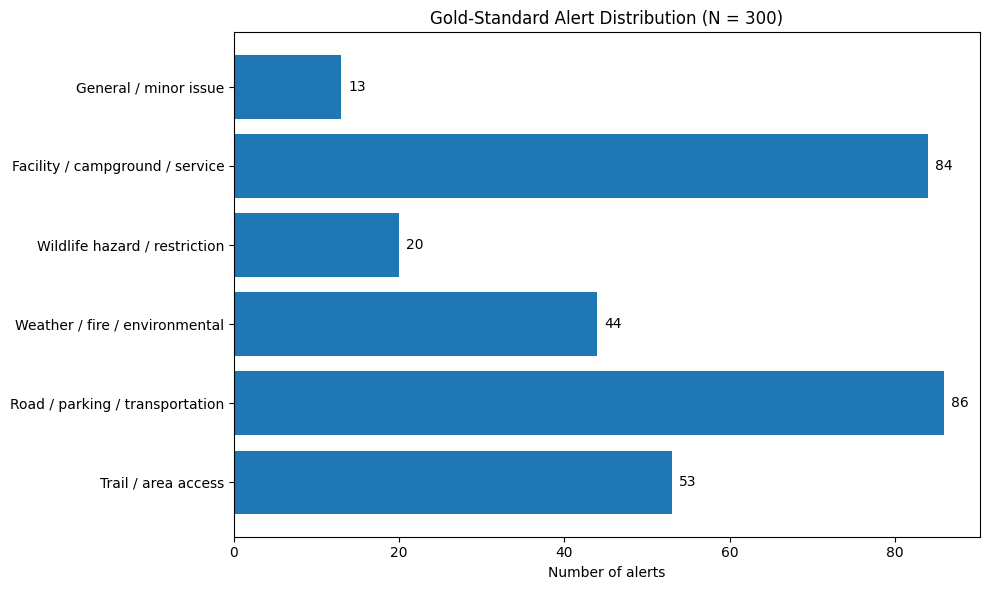

In [ ]:

class_distribution = (
    modeling_df["primary_label"]
    .value_counts()
    .reindex(PRIMARY_LABELS, fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [
        DISPLAY_LABELS[label]
        for label in class_distribution.index
    ],
    class_distribution.values,
)

ax.set_xlabel("Number of alerts")
ax.set_title(
    "Gold-Standard Alert Distribution (N = 300)"
)

for index, value in enumerate(
    class_distribution.values
):
    ax.text(
        value + 0.8,
        index,
        str(value),
        va="center",
    )

plt.tight_layout()
plt.show()


## Figure 2. Final model comparison

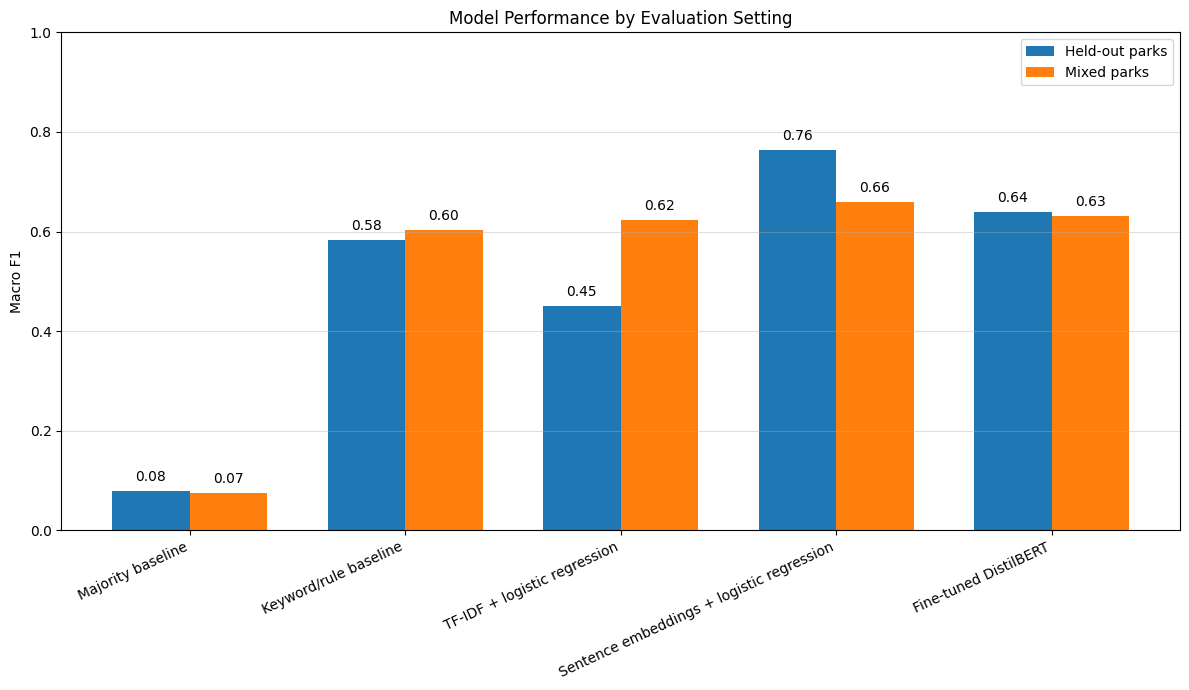

In [ ]:

model_order = [
    "Majority baseline",
    "Keyword/rule baseline",
    "TF-IDF + logistic regression",
    "Sentence embeddings + logistic regression",
    "Fine-tuned DistilBERT",
]

comparison_plot_df = (
    test_metrics_df
    .pivot_table(
        index="model",
        columns="evaluation_setting",
        values="macro_f1",
        aggfunc="first",
    )
    .reindex(model_order)
)

x = np.arange(
    len(comparison_plot_df)
)
width = 0.36

fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(
    x - width / 2,
    comparison_plot_df[
        "Held-out parks"
    ],
    width,
    label="Held-out parks",
)

ax.bar(
    x + width / 2,
    comparison_plot_df[
        "Mixed parks"
    ],
    width,
    label="Mixed parks",
)

ax.set_ylabel("Macro F1")
ax.set_title(
    "Model Performance by Evaluation Setting"
)
ax.set_xticks(x)
ax.set_xticklabels(
    comparison_plot_df.index,
    rotation=25,
    ha="right",
)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(
    axis="y",
    linewidth=0.8,
    alpha=0.4,
)

for index, value in enumerate(
    comparison_plot_df[
        "Held-out parks"
    ]
):
    ax.text(
        index - width / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
    )

for index, value in enumerate(
    comparison_plot_df[
        "Mixed parks"
    ]
):
    ax.text(
        index + width / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
    )

plt.tight_layout()
plt.show()


## Figure 3. Held-out DistilBERT confusion matrix

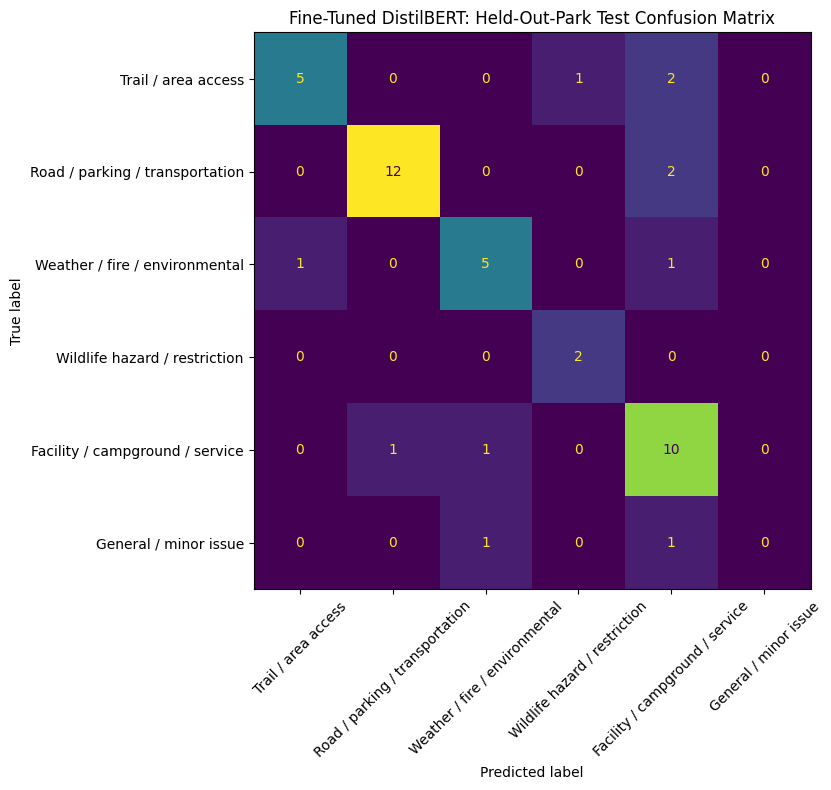

In [ ]:

heldout_test_predictions = (
    distilbert_predictions_df.loc[
        distilbert_predictions_df[
            "evaluation_setting"
        ].eq("Held-out parks")
        & distilbert_predictions_df[
            "partition"
        ].eq("test")
    ]
)

matrix = confusion_matrix(
    heldout_test_predictions[
        "primary_label"
    ],
    heldout_test_predictions[
        "predicted_label"
    ],
    labels=PRIMARY_LABELS,
)

fig, ax = plt.subplots(figsize=(10, 8))

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=[
        DISPLAY_LABELS[label]
        for label in PRIMARY_LABELS
    ],
)

display_matrix.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
    colorbar=False,
)

ax.set_title(
    "Fine-Tuned DistilBERT: Held-Out-Park Test Confusion Matrix"
)

plt.tight_layout()
plt.show()


## Figure 4. Held-out DistilBERT per-class F1

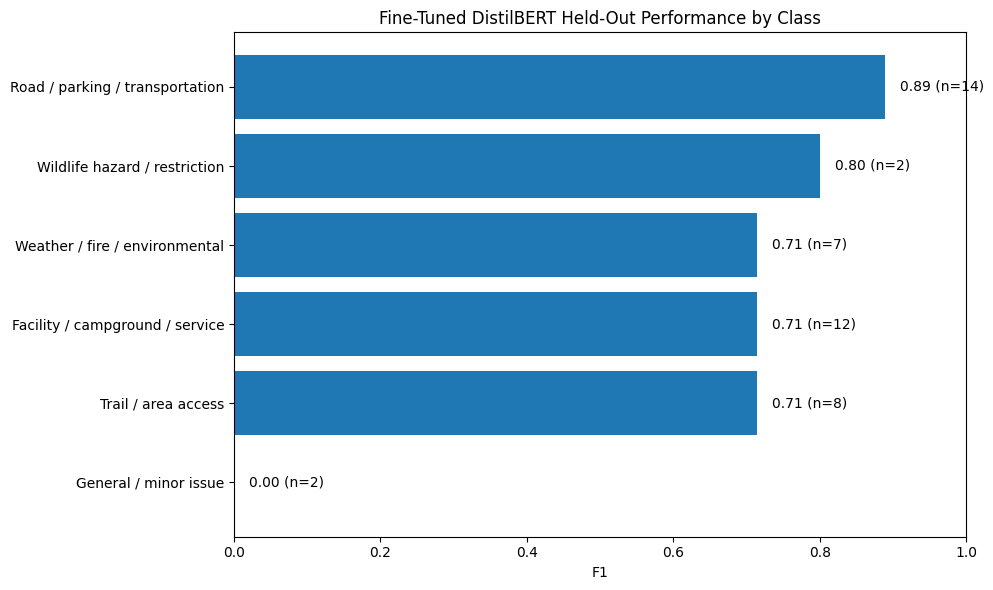

In [ ]:

heldout_distilbert_class_df = (
    distilbert_class_metrics_df.loc[
        distilbert_class_metrics_df[
            "evaluation_setting"
        ].eq("Held-out parks")
        & distilbert_class_metrics_df[
            "partition"
        ].eq("test")
    ]
    .sort_values(
        "f1",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    heldout_distilbert_class_df[
        "display_label"
    ],
    heldout_distilbert_class_df["f1"],
)

ax.set_xlabel("F1")
ax.set_title(
    "Fine-Tuned DistilBERT Held-Out Performance by Class"
)
ax.set_xlim(0, 1)

for index, row in enumerate(
    heldout_distilbert_class_df.itertuples()
):
    ax.text(
        row.f1 + 0.02,
        index,
        f"{row.f1:.2f} (n={row.support})",
        va="center",
    )

plt.tight_layout()
plt.show()


## Figure 5. Sentence-embedding title ablation

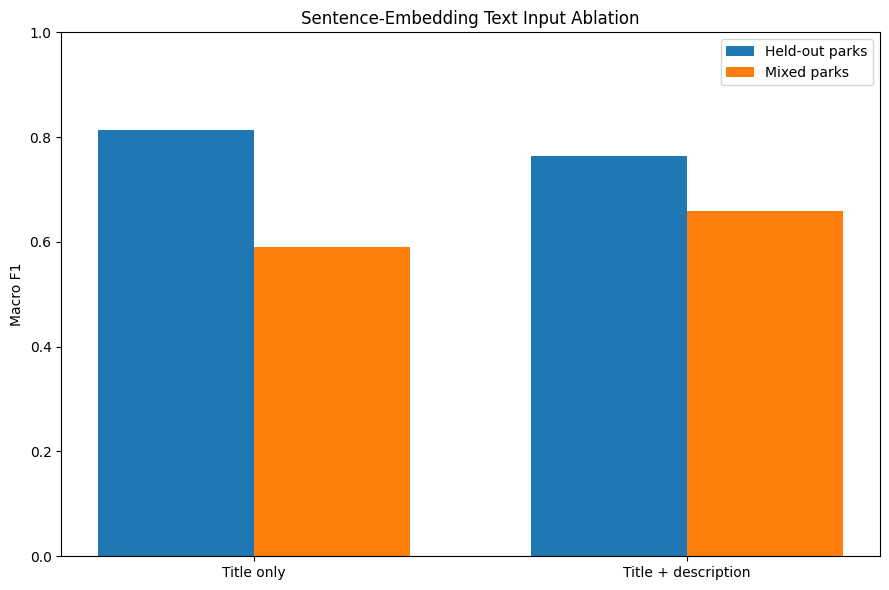

In [ ]:

if EMBEDDING_ABLATION_PATH is not None:
    embedding_ablation_df = pd.read_csv(
        EMBEDDING_ABLATION_PATH
    )

    ablation_plot_df = (
        embedding_ablation_df
        .pivot_table(
            index="text_version",
            columns="evaluation_setting",
            values="test_macro_f1",
            aggfunc="first",
        )
        .reindex([
            "title_only",
            "title_plus_description",
        ])
    )

    x = np.arange(
        len(ablation_plot_df)
    )
    width = 0.36

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.bar(
        x - width / 2,
        ablation_plot_df[
            "Held-out parks"
        ],
        width,
        label="Held-out parks",
    )

    ax.bar(
        x + width / 2,
        ablation_plot_df[
            "Mixed parks"
        ],
        width,
        label="Mixed parks",
    )

    ax.set_ylabel("Macro F1")
    ax.set_title(
        "Sentence-Embedding Text Input Ablation"
    )
    ax.set_xticks(x)
    ax.set_xticklabels([
        "Title only",
        "Title + description",
    ])
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print(
        "Embedding ablation file was not found."
    )


## 14. Export results and figures

In [ ]:

figures_dir = output_dir / "figures"
figures_dir.mkdir(
    parents=True,
    exist_ok=True,
)

# Recreate and save Figure 1.
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [
        DISPLAY_LABELS[label]
        for label in class_distribution.index
    ],
    class_distribution.values,
)
ax.set_xlabel("Number of alerts")
ax.set_title(
    "Gold-Standard Alert Distribution (N = 300)"
)
for index, value in enumerate(
    class_distribution.values
):
    ax.text(
        value + 0.8,
        index,
        str(value),
        va="center",
    )
plt.tight_layout()
fig.savefig(
    figures_dir / "figure_1_class_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close(fig)

# Recreate and save Figure 2.
x_comparison = np.arange(len(comparison_plot_df))
comparison_width = 0.36

fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(
    x_comparison - comparison_width / 2,
    comparison_plot_df["Held-out parks"],
    comparison_width,
    label="Held-out parks",
)
ax.bar(
    x_comparison + comparison_width / 2,
    comparison_plot_df["Mixed parks"],
    comparison_width,
    label="Mixed parks",
)
ax.set_ylabel("Macro F1")
ax.set_title(
    "Model Performance by Evaluation Setting"
)
ax.set_xticks(x_comparison)
ax.set_xticklabels(
    comparison_plot_df.index,
    rotation=25,
    ha="right",
)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(
    axis="y",
    linewidth=0.8,
    alpha=0.4,
)
plt.tight_layout()
fig.savefig(
    figures_dir / "figure_2_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close(fig)

# Save Figure 3.
fig, ax = plt.subplots(figsize=(10, 8))
display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=[
        DISPLAY_LABELS[label]
        for label in PRIMARY_LABELS
    ],
)
display_matrix.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
    colorbar=False,
)
ax.set_title(
    "Fine-Tuned DistilBERT: Held-Out-Park Test Confusion Matrix"
)
plt.tight_layout()
fig.savefig(
    figures_dir / "figure_3_distilbert_heldout_confusion.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close(fig)

# Save Figure 4.
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    heldout_distilbert_class_df[
        "display_label"
    ],
    heldout_distilbert_class_df["f1"],
)
ax.set_xlabel("F1")
ax.set_title(
    "Fine-Tuned DistilBERT Held-Out Performance by Class"
)
ax.set_xlim(0, 1)
for index, row in enumerate(
    heldout_distilbert_class_df.itertuples()
):
    ax.text(
        row.f1 + 0.02,
        index,
        f"{row.f1:.2f} (n={row.support})",
        va="center",
    )
plt.tight_layout()
fig.savefig(
    figures_dir / "figure_4_distilbert_per_class_f1.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close(fig)

# Export tables.
distilbert_metrics_df.to_csv(
    output_dir / "distilbert_overall_metrics.csv",
    index=False,
)

distilbert_class_metrics_df.to_csv(
    output_dir / "distilbert_per_class_metrics.csv",
    index=False,
)

distilbert_predictions_df.to_csv(
    output_dir / "distilbert_predictions.csv",
    index=False,
)

distilbert_errors_df.to_csv(
    output_dir / "distilbert_heldout_errors_for_coding.csv",
    index=False,
)

combined_metrics_df.to_csv(
    output_dir / "all_models_metrics.csv",
    index=False,
)

generalization_gap_df.to_csv(
    output_dir / "all_models_generalization_gap.csv",
    index=False,
)

grouped_cv_results_df.to_csv(
    output_dir / "embedding_grouped_cv_folds.csv",
    index=False,
)

grouped_cv_summary_df.to_csv(
    output_dir / "embedding_grouped_cv_summary.csv",
    index=False,
)

with pd.ExcelWriter(
    output_dir / "final_modeling_results_summary.xlsx",
    engine="openpyxl",
) as writer:
    test_metrics_df.to_excel(
        writer,
        sheet_name="Final_Test_Metrics",
        index=False,
    )
    generalization_gap_df.to_excel(
        writer,
        sheet_name="Generalization_Gap",
        index=False,
    )
    distilbert_class_metrics_df.to_excel(
        writer,
        sheet_name="DistilBERT_Per_Class",
        index=False,
    )
    grouped_cv_results_df.to_excel(
        writer,
        sheet_name="Grouped_CV_Folds",
        index=False,
    )
    grouped_cv_summary_df.to_excel(
        writer,
        sheet_name="Grouped_CV_Summary",
        index=False,
    )
    distilbert_errors_df.to_excel(
        writer,
        sheet_name="Errors_For_Coding",
        index=False,
    )

run_summary = {
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "learning_rate": LEARNING_RATE,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "weight_decay": WEIGHT_DECAY,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "class_weighted_loss": True,
    "seed": RANDOM_STATE,
    "primary_evaluation": "held-out parks",
    "selection_metric": "validation Macro F1",
    "heldout_best_checkpoint": (
        heldout_run["best_checkpoint"]
    ),
    "mixed_best_checkpoint": (
        mixed_run["best_checkpoint"]
    ),
}

with open(
    output_dir / "distilbert_run_configuration.json",
    "w",
) as file:
    json.dump(
        run_summary,
        file,
        indent=2,
    )

print(
    "Saved all outputs to:",
    output_dir.resolve(),
)

for path in sorted(
    output_dir.rglob("*")
):
    if path.is_file():
        print("-", path.relative_to(output_dir))


Saved all outputs to: /content/nps_distilbert_outputs
- all_models_generalization_gap.csv
- all_models_metrics.csv
- distilbert_heldout_errors_for_coding.csv
- distilbert_overall_metrics.csv
- distilbert_per_class_metrics.csv
- distilbert_predictions.csv
- distilbert_run_configuration.json
- embedding_grouped_cv_folds.csv
- embedding_grouped_cv_summary.csv
- figures/figure_1_class_distribution.png
- figures/figure_2_model_comparison.png
- figures/figure_3_distilbert_heldout_confusion.png
- figures/figure_4_distilbert_per_class_f1.png
- final_modeling_results_summary.xlsx
- held_out_parks/checkpoint-108/config.json
- held_out_parks/checkpoint-108/model.safetensors
- held_out_parks/checkpoint-108/optimizer.pt
- held_out_parks/checkpoint-108/rng_state.pth
- held_out_parks/checkpoint-108/scaler.pt
- held_out_parks/checkpoint-108/scheduler.pt
- held_out_parks/checkpoint-108/tokenizer.json
- held_out_parks/checkpoint-108/tokenizer_config.json
- held_out_parks/checkpoint-108/trainer_state.jso